In [1]:
import numpy as np
import pylab as plt
plt.rcParams['figure.figsize'] = [8, 8]
plt.rcParams['font.size'] = 12
import emcee
import scipy.stats
import corner
import dynesty
from dynesty import utils as dyfunc
from dynesty import plotting as dyplot
import warnings

/Users/dgerosa/box/lib/python3.11/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [2]:
data= np.load('transient.npy')

First, always start with a quick look at the data

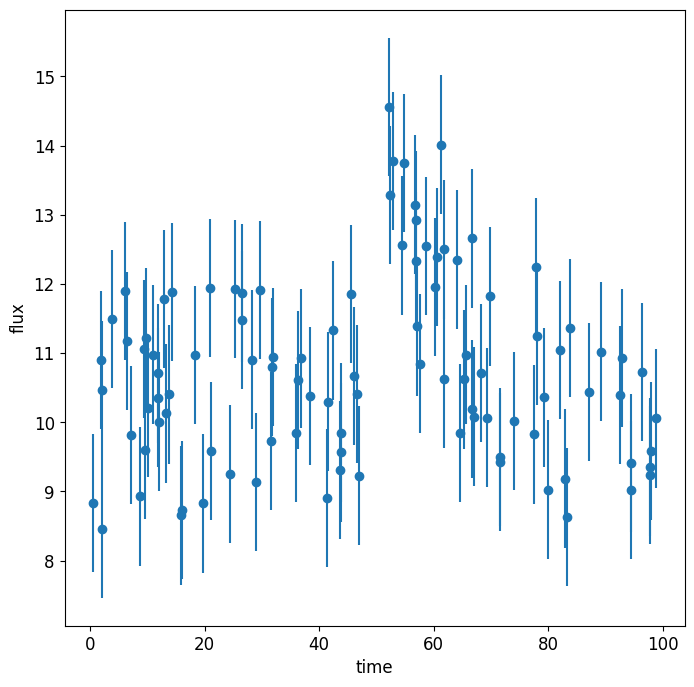

In [3]:
t,y,yerr=data.T
plt.errorbar(t,y,yerr=yerr,fmt='o')
plt.xlabel("time")
plt.ylabel("flux");

These are the old burst model and the new gaussian profile model:

In [7]:
def burst(theta,t):
    A,b,t0,alpha=theta 
    return np.where(t<t0,b,b+A*np.exp(-alpha*(t-t0)))

def gprofile(theta,t):
    A,b,t0,sigmaW=theta     
    return b+A*np.exp(-(((t-t0)/sigmaW)**2 ) / 2)

t0min,t0max = 0,100
Amin,Amax=0,50
bmin,bmax=0,50
alphamin,alphamax=np.exp(-5),np.exp(5)
sigmaWmin,sigmaWmax=np.exp(-2),np.exp(2)

First, let's reproduce our previous results using dynesty

In [8]:
ndim = 4

def loglike(theta, data, model):
    x, y, sigma_y = data.T
    if model =='burst':
        y_fit = burst(theta, x)
    elif model == 'gprofile':
        y_fit = gprofile(theta, x)

    # Note I'm not tracking the normalization here! 
    # Ok because here I only care about the ratio between two evidences, not the evidence itself
    return -0.5 * np.sum((y-y_fit)**2 / sigma_y**2 ) 


def ptform(u,model):
    """Transforms the uniform random variables `u ~ Unif[0., 1.)`
    to the parameters of interest."""

    x = np.array(u)  # copy u

    x[0] = scipy.stats.uniform(loc=Amin,scale=Amax-Amin).ppf(u[0])
    x[1] = scipy.stats.uniform(loc=bmin,scale=bmax-bmin).ppf(u[1])
    x[2] = scipy.stats.uniform(loc=t0min,scale=t0max-t0min).ppf(u[2])
   
    if model =='burst':
        x[3] = scipy.stats.loguniform.ppf(u[3],alphamin,alphamax)
    elif model =='gprofile':
        x[3] = scipy.stats.loguniform.ppf(u[3],sigmaWmin,sigmaWmax)
        #x[3] = scipy.stats.uniform(loc=sigmaWmin,scale=sigmaWmax-sigmaWmin).ppf(u[3])

    return x

In [9]:
with warnings.catch_warnings():
    # Potentially dangerous, but hey I know what I'm doing. 
    # Those warnings come from regions where the likelihood is ~zero
    warnings.simplefilter("ignore", category=RuntimeWarning)

    # Define and run sampler
    sampler = dynesty.NestedSampler(loglike, ptform, ndim,logl_args=[data,'burst'],ptform_args=['burst'],nlive=300)
    sampler.run_nested()
    sresults = sampler.results

2171it [00:47,  9.23it/s, bound: 121 | nc: 206 | ncall: 59617 | eff(%):  3.642 | loglstar:   -inf < -86.789 <    inf | logz: -92.959 +/-  0.134 | dlogz: 34.995 >  0.309]/Users/dgerosa/box/lib/python3.11/site-packages/dynesty/bounding.py:707: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (bootstrap=0)
  warnings.warn(
2203it [00:57, 11.10it/s, bound: 130 | nc: 45 | ncall: 71461 | eff(%):  3.083 | loglstar:   -inf < -86.533 <    inf | logz: -92.920 +/-  0.134 | dlogz: 34.849 >  0.309] /Users/dgerosa/box/lib/python3.11/site-packages/dynesty/bounding.py:707: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are

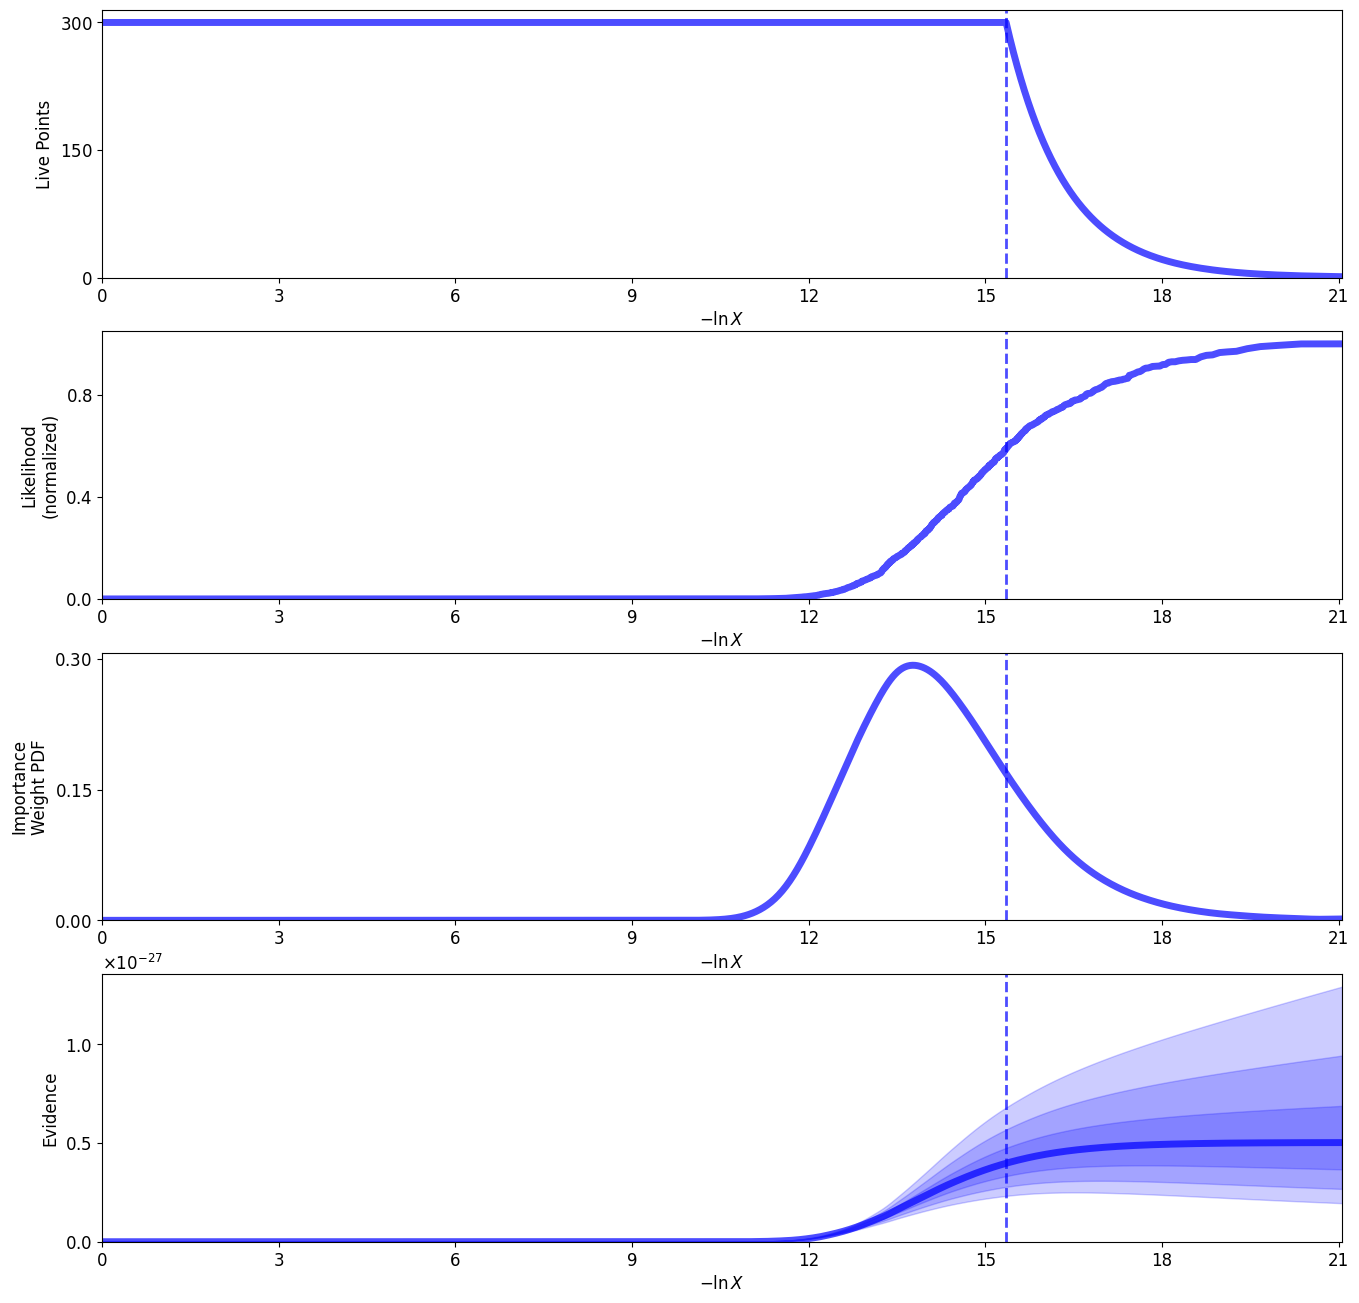

In [10]:
rfig, raxes = dyplot.runplot(sresults)

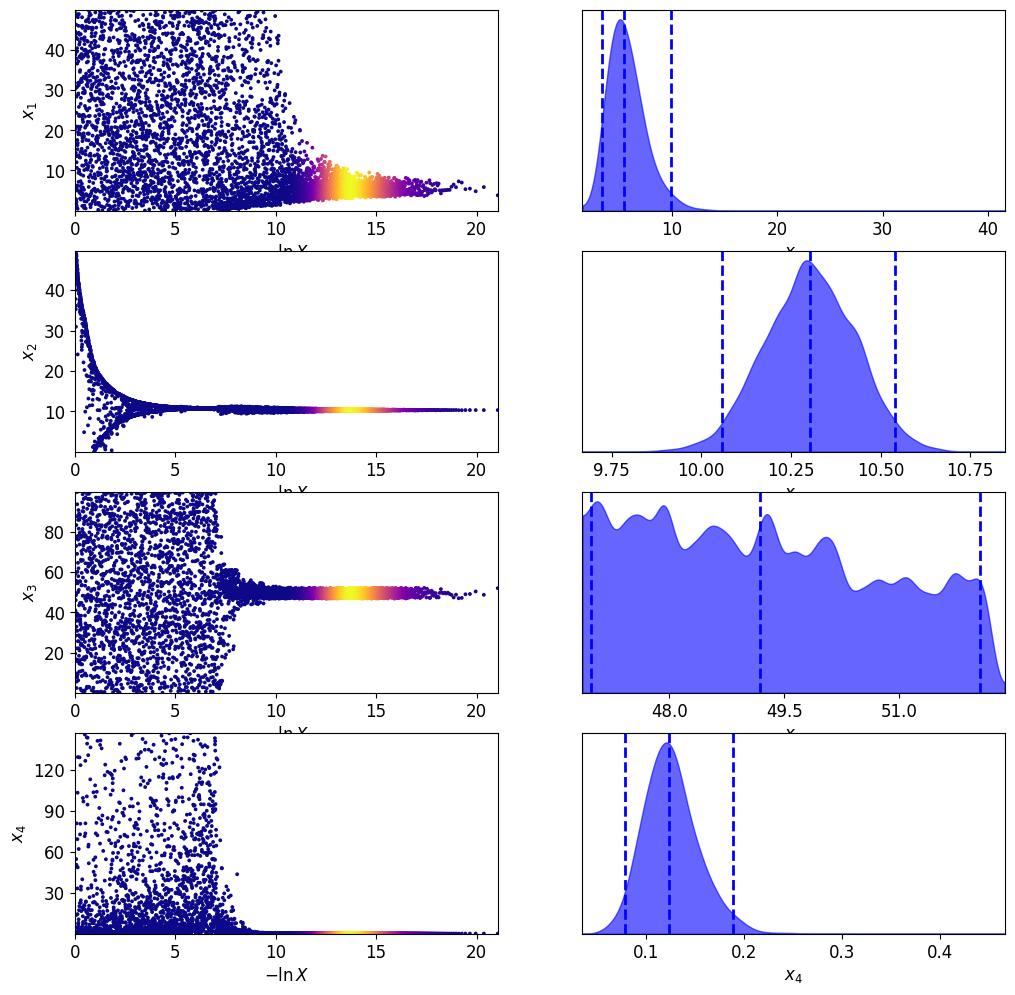

In [11]:
tfig, taxes = dyplot.traceplot(sresults)

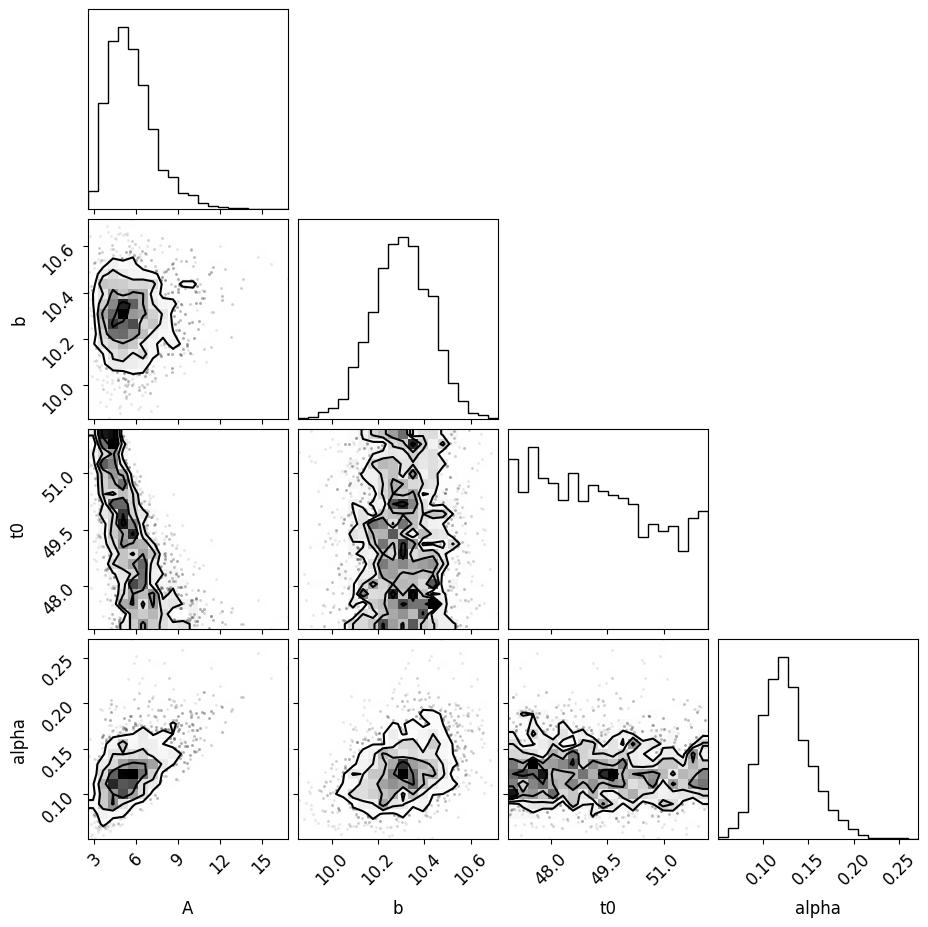

In [12]:
samples = sresults.samples  # samples
weights = np.exp(sresults.logwt - sresults.logz[-1])  # normalized weights

labels = ["A","b","t0","alpha"]

samples_equal = dyfunc.resample_equal(samples, weights)
corner.corner(samples_equal,labels=labels);

In [13]:
quantiles = [dyfunc.quantile(samps, [0.05, 0.5, 0.95], weights=weights)
             for samps in samples.T]
for q,l in zip(quantiles,labels):
    low,med,up=q
    print(l+"   "+str(med)+" +"+str(up-med)+" -"+str(med-low))

A   5.422054427185757 +3.500400520652609 -1.8367937973817128
b   10.302328249975062 +0.19959547328016924 -0.2110881461994687
t0   49.18323606579371 +2.6872705756898227 -2.113963168457147
alpha   0.12352950155931144 +0.05128752288660107 -0.03764114748246701


In [14]:
sresults.summary()

Summary
nlive: 300
niter: 4613
ncall: 114606
eff(%):  4.287
logz: -62.858 +/-  0.315


Ok now let's move on with the Gaussian profile:

In [15]:
sampler = dynesty.NestedSampler(loglike, ptform, ndim,logl_args=[data,'gprofile'],ptform_args=['gprofile'],nlive=300)
sampler.run_nested()
sresults2 = sampler.results

2413it [00:34,  5.74it/s, bound: 89 | nc: 286 | ncall: 43674 | eff(%):  5.525 | loglstar:   -inf < -86.770 <    inf | logz: -94.415 +/-  0.149 | dlogz: 32.371 >  0.309]/Users/dgerosa/box/lib/python3.11/site-packages/dynesty/bounding.py:707: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (bootstrap=0)
  warnings.warn(
2415it [00:36,  3.62it/s, bound: 91 | nc: 1608 | ncall: 45441 | eff(%):  5.315 | loglstar:   -inf < -86.731 <    inf | logz: -94.411 +/-  0.149 | dlogz: 32.359 >  0.309]/Users/dgerosa/box/lib/python3.11/site-packages/dynesty/bounding.py:707: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are 

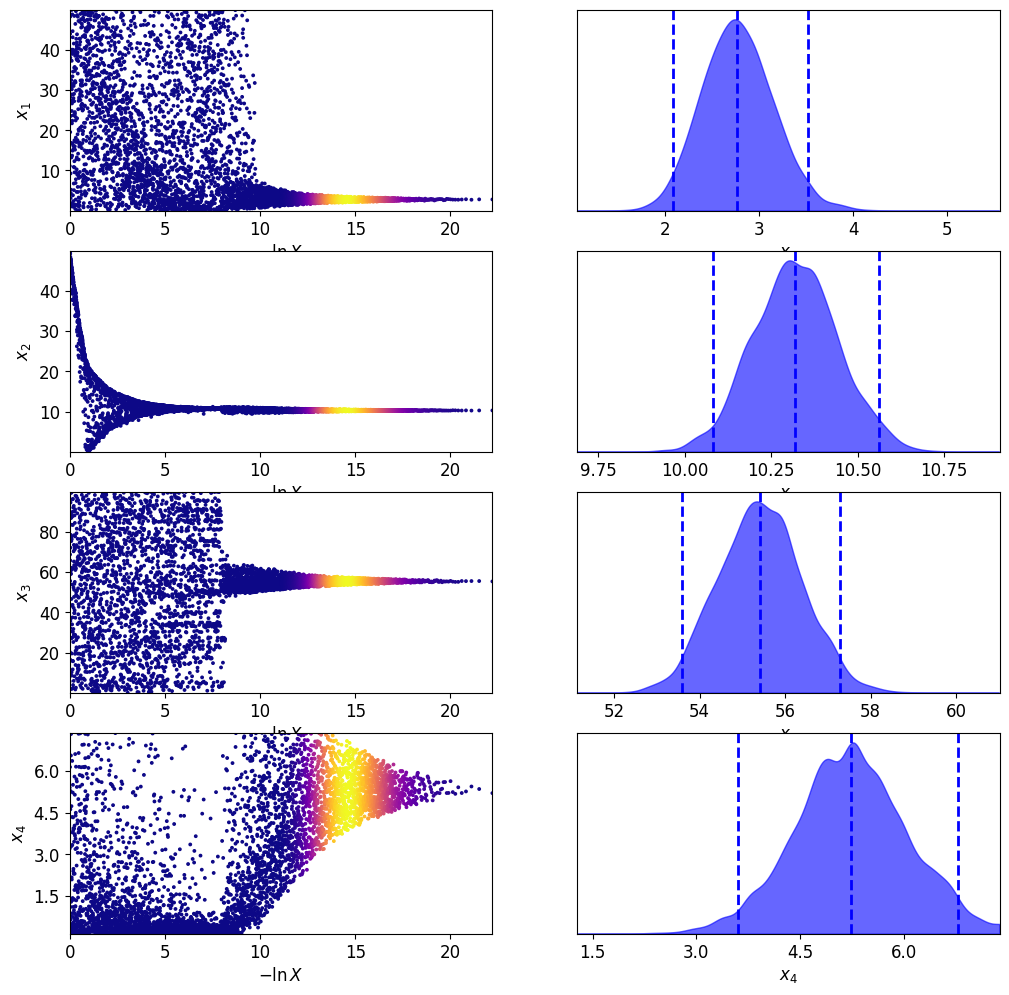

In [16]:
tfig, taxes = dyplot.traceplot(sresults2)

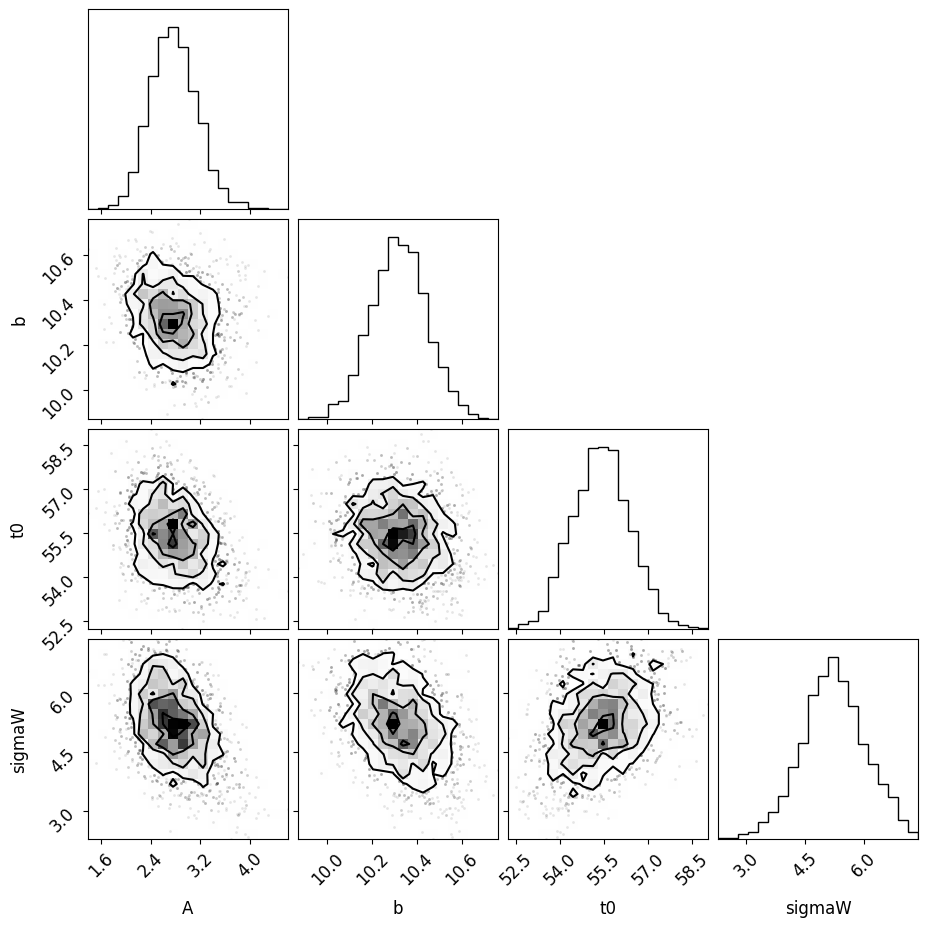

In [17]:
samples = sresults2.samples  # samples
weights = np.exp(sresults2.logwt - sresults2.logz[-1])  # normalized weights

labels = ["A","b","t0","sigmaW"]

samples_equal = dyfunc.resample_equal(samples, weights)
corner.corner(samples_equal,labels=labels);

In [18]:
sresults2.summary()

Summary
nlive: 300
niter: 4956
ncall: 161260
eff(%):  3.259
logz: -67.691 +/-  0.323


Now compute the odds ratio (assuming equal hyperpriors) between the two models:

In [19]:
np.exp(sresults.logz[-1])/np.exp(sresults2.logz[-1])

np.float64(125.61145662959846)

This is "very strong" evidence in favour of the burst model

Something I haven't done: 
- check if this number is robust with respect to the nested sampling hyperparameters (number of live points, dlogz threshold where the fit is terminated)
- Assign an error to this estimate of the Bayes factor.

Let's plot some models

Text(0, 0.5, 'flux')

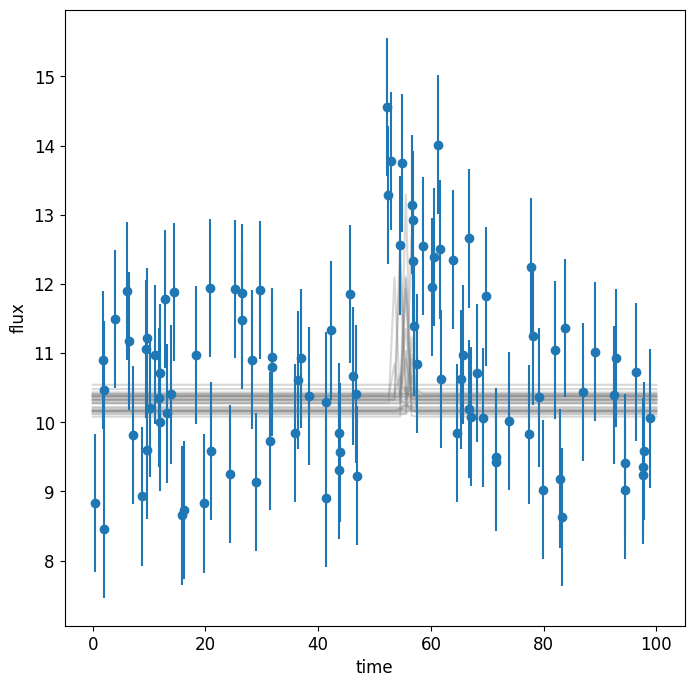

In [20]:
tgrid=np.linspace(0,100,100)

chosen_samples= samples_equal[np.random.choice(len(samples_equal),size=30)]

for chosen_theta in chosen_samples:

    ygrid =  burst(chosen_theta,tgrid)
    plt.plot(tgrid,ygrid,alpha=0.3,c='gray')
    
plt.errorbar(t,y,yerr=yerr,fmt='o')
plt.xlabel("time")
plt.ylabel("flux")

Indeed, look how badly this is describing the data... 

Remember this does not tell you that a model is correct, only that one is better than the other.

In [21]:
### Some tests I've done


### Here I played a bit with the fit by hand...
# tgrid=np.linspace(0,100,100)
# t0_quick=50
# A_quick=5
# b_quick=10
# sigmaW_quick=2
# theta_quick= np.array([A_quick,b_quick,t0_quick,sigmaW_quick])
# ygrid =  gprofile(theta_quick,tgrid)
# plt.errorbar(t,y,yerr=yerr,fmt='o')
# plt.xlabel("time")
# plt.ylabel("flux")
# plt.plot(tgrid,ygrid)

In [22]:
### Some tests I've done

### Here I convinced myself I understand what ppf is doing

# def ptform(u,model):
#     """Transforms the uniform random variables `u ~ Unif[0., 1.)`
#     to the parameters of interest."""
# 
#     x = np.array(u)  # copy u
# 
#     x[0] = scipy.stats.uniform(loc=Amin,scale=Amax-Amin).ppf(u[0])
#     x[1] = scipy.stats.uniform(loc=bmin,scale=bmax-bmin).ppf(u[1])
#     x[2] = scipy.stats.uniform(loc=t0min,scale=t0max-t0min).ppf(u[2])
# 
#     if model =='burst':
#         x[3] = scipy.stats.loguniform.ppf(u[3],alphamin,alphamax)
#     elif model =='gprofile':
#         x[3] = scipy.stats.loguniform.ppf(u[3],sigmaWmin,sigmaWmax)
#         #x[3] = scipy.stats.uniform(loc=sigmaWmin,scale=sigmaWmax-sigmaWmin).ppf(u[3])
# 
#     return x

# myu= np.random.uniform(0,1,4000).reshape(4,1000)
# myp = ptform(myu, 'burst')
# plt.hist(np.log(myp[3]))
# y=scipy.stats.loguniform.ppf(np.random.uniform(0,1,1000),sigmaWmin,sigmaWmax)
# plt.hist(np.log(y))